In [17]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten
import numpy as np

from hoda_loader import load_hoda

In [18]:
X_train_original, y_train_original, X_test_original, y_test_original = load_hoda()

In [19]:
X_train_original = X_train_original.reshape(-1, 5, 5)
X_test_original = X_test_original.reshape(-1, 5, 5)

In [20]:
X_train_original.shape

(1000, 5, 5)

In [21]:
X_test_original.shape

(200, 5, 5)

In [22]:
# Preprocessing input data for keras
y_train = y_train_original
y_test = y_test_original

In [23]:
y_train_original[:5]

array([6, 5, 0, 2, 7], dtype=uint8)

In [24]:
y_train[:5]

array([6, 5, 0, 2, 7], dtype=uint8)

In [25]:
# Normalize the data (0 - 1)
X_train = X_train_original.astype('float32')
X_test = X_test_original.astype('float32')
X_train /= 255
X_test /= 255

In [26]:
# Model architecture
model = Sequential()
model.add(Flatten(input_shape=(5, 5)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,314 (9.04 KB)

 Trainable params: 2,314 (9.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
import tensorflow as tf

In [29]:
# compile model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='rmsprop', metrics=['accuracy'])

In [30]:
# fitting
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.1475 - loss: 2.2982 - val_accuracy: 0.2550 - val_loss: 2.1776
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3137 - loss: 2.0921 - val_accuracy: 0.4050 - val_loss: 2.0017
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4925 - loss: 1.9277 - val_accuracy: 0.5200 - val_loss: 1.8391
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5725 - loss: 1.7743 - val_accuracy: 0.6350 - val_loss: 1.6880
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6475 - loss: 1.6264 - val_accuracy: 0.6700 - val_loss: 1.5446
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6862 - loss: 1.4846 - val_accuracy: 0.7000 - val_loss: 1.4032
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7262 - loss: 1.3482 - val_accuracy: 0.7350 - val_loss: 1.2721
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7613 - loss: 1.2194 - val_accuracy: 0.

In [31]:
import matplotlib.pyplot as plt

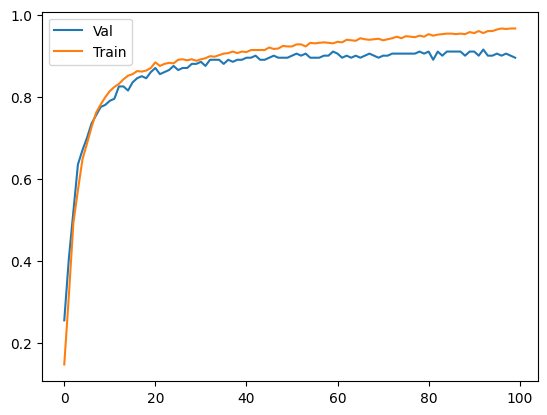

In [32]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.legend(["Val", "Train"]);

In [33]:
# Evaluation model on the test data
loss, acc = model.evaluate(X_test, y_test)
print("\nTesting loss: %.2f, acc: %.2f%%"%(loss, acc))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9300 - loss: 0.2471

Testing loss: 0.25, acc: 0.93%


In [34]:
y_test[1]

np.uint8(2)

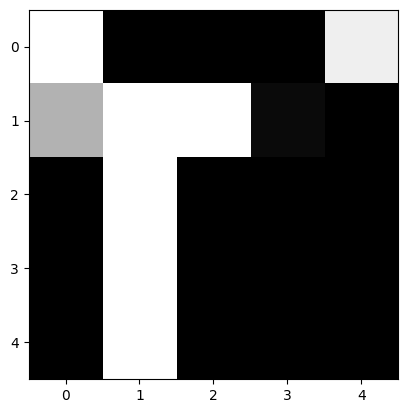

In [35]:
plt.imshow(X_test[1].reshape(5, 5), cmap='gray');

In [36]:
model.predict(X_test)[1].argmax()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


np.int64(2)

In [37]:
model.predict(X_test).max(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([0.9995553 , 0.77761155, 0.866199  , 0.33700794, 0.99083215,
       0.99333775, 0.9269774 , 0.88252044, 0.96803254, 0.69246423,
       0.7388541 , 0.99994516, 0.7125204 , 0.999592  , 0.62423146,
       0.9955735 , 0.81675285, 0.9990859 , 0.886852  , 0.99516654,
       0.9958358 , 0.94792646, 0.9957073 , 0.92120034, 0.95031035,
       0.97643673, 0.99988663, 0.99800104, 0.99577725, 0.99142504,
       0.53580177, 0.9978708 , 0.9399569 , 0.99980253, 0.9842487 ,
       0.5343793 , 0.9989938 , 0.61030614, 0.99043244, 0.9992612 ,
       0.9915006 , 0.91001546, 0.4712196 , 0.7908899 , 0.99653757,
       0.98434293, 0.96847737, 0.90231067, 0.99648947, 0.982173  ,
       0.99121714, 0.74239635, 0.9701291 , 0.99936575, 0.636147  ,
       0.82545304, 0.99787366, 0.9787805 , 0.970227  , 0.99883825,
       0.9826659 , 0.9995765 , 0.99491006, 0.99867153, 0.5287908 ,
       0.99190485, 0.73381734, 0.65842146, 0.6694537 , 0.980349  ,
       0.9159205 , 0.9999144 , 0.9724583 , 0.9693951 , 0.98602

In [46]:
accuracy = np.mean(model.predict(X_test).argmax(axis=1) == y_test)
print(accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
0.93
